In [2]:
import os
import sys
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

DEVICE = torch.device("cuda")


/depot/jgmakin/data/bilal/env/diffusion/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### functions...

In [3]:
# ============================================================
# Core: Compute Drift V and Loss (from toy_mean_drift.py)
# ============================================================

def compute_drift(gen: torch.Tensor, pos: torch.Tensor, temp: float = 0.05):
    """
    Compute drift field V with attention-based kernel.
    
    Args:
        gen: Generated samples [G, D]
        pos: Data samples [P, D]
        temp: Temperature for softmax kernel
    
    Returns:
        V: Drift vectors [G, D]
    """
    targets = torch.cat([gen, pos], dim=0)
    G = gen.shape[0]

    dist = torch.cdist(gen, targets)
    dist[:, :G].fill_diagonal_(1e6)  # mask self
    kernel = (-dist / temp).exp() # unnormalized kernel

    normalizer = kernel.sum(dim=-1, keepdim=True) #* kernel.sum(dim=-2, keepdim=True) # normalize along both dimensions, which we found to slightly improve performance
    normalizer = normalizer.clamp_min(1e-12).sqrt() 
    normalized_kernel = kernel / normalizer

    pos_coeff = normalized_kernel[:, G:] * normalized_kernel[:, :G].sum(dim=-1, keepdim=True)
    pos_V = pos_coeff @ targets[G:]
    neg_coeff = normalized_kernel[:, :G] * normalized_kernel[:, G:].sum(dim=-1, keepdim=True)
    neg_V = neg_coeff @ targets[:G]

    return pos_V - neg_V

def drifting_loss(gen: torch.Tensor, pos: torch.Tensor, compute_drift):
    """Drifting loss: MSE(gen, stopgrad(gen + V))."""
    with torch.no_grad():
        V = compute_drift(gen, pos)
        target = (gen + V).detach()
    return F.mse_loss(gen, target)


# ============================================================
# Toy Dataset Samplers (minimal; copied from toy_mean_drift.py)
# ============================================================

def sample_checkerboard(n: int, noise: float = 0.05, seed: int = None) -> torch.Tensor:
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    b = torch.randint(0, 2, (n,), generator=g)
    i = torch.randint(0, 2, (n,), generator=g) * 2 + b
    j = torch.randint(0, 2, (n,), generator=g) * 2 + b
    u = torch.rand(n, generator=g)
    v = torch.rand(n, generator=g)
    pts = torch.stack([i + u, j + v], dim=1) - 2.0
    pts = pts / 2.0
    if noise > 0:
        pts = pts + noise * torch.randn(pts.shape, generator=g)
    return pts


def sample_swiss_roll(n: int, noise: float = 0.03, seed: int = None) -> torch.Tensor:
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    u = torch.rand(n, generator=g)
    t = 0.5 * math.pi + 4.0 * math.pi * u
    pts = torch.stack([t * torch.cos(t), t * torch.sin(t)], dim=1)
    pts = pts / (pts.abs().max() + 1e-8)
    if noise > 0:
        pts = pts + noise * torch.randn(pts.shape, generator=g)
    return pts

def sample_gmm(n: int, noise: float = 0.03, seed: int = None) -> torch.Tensor:
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    r = 1
    n_components = 5
    centroids = torch.tensor([
        [r * math.cos(2 * math.pi * i / n_components), r * math.sin(2 * math.pi * i / n_components)]
        for i in range(n_components)
    ])
    component_ids = torch.randint(0, n_components, (n,))
    pts = centroids[component_ids]
    if noise > 0:
        pts = pts + noise * torch.randn(pts.shape, generator=g)
    return pts

def nearest_drift(neg: torch.Tensor, pos: torch.Tensor, temp: float = 0.05) -> torch.Tensor:
    """
    Compute average vector field between samples from two distributions.
    """
    vectors = - pos[None,:] + neg[:,None]
    distances = vectors.norm(dim=-1)
    kernel = (-distances / temp).exp()
    normalized_kernel = kernel / kernel.sum(dim=-1, keepdim=True)
    weighted_vectors = normalized_kernel[:,:,None]*vectors
    # field = weighted_vectors.sum(dim=1)
    # indices = normalized_kernel.argmax(dim=-1)
    # field = vectors[torch.arange(indices.shape[0]), indices]

    indices = normalized_kernel.argmax(dim=0)
    field = vectors[indices, torch.arange(indices.shape[0])]
    return field

def avg_drift(neg: torch.Tensor, pos: torch.Tensor, temp: float = 1.0) -> torch.Tensor:
    """
    Compute average vector field between samples from two distributions.
    """
    vectors = - pos[None,:] + neg[:,None]
    distances = vectors.norm(dim=-1)
    kernel = (-distances / temp).exp()
    normalized_kernel = kernel / kernel.sum(dim=-1, keepdim=True)
    weighted_vectors = normalized_kernel[:,:,None]*vectors
    field = weighted_vectors.sum(dim=0)

    # indices = normalized_kernel.argmax(dim=-1)
    # field = vectors[torch.arange(indices.shape[0]), indices]
    # indices = normalized_kernel.argmax(dim=0)
    # field = vectors[indices, torch.arange(indices.shape[0])]
    return field

In [29]:
# data = sample_gmm(10000, noise=0.05, seed=42)
# prior = torch.randn_like(data) * 0.1

batch_size = 32
num_batches = data.shape[0] // batch_size

neg = []
pos = []
# nearest_drift_fields = []
# straight_fields = []
# reverse_drift_fields = []
drift_fields = []
for idx in range(num_batches):
    neg.append(prior[idx*batch_size:(idx+1)*batch_size])
    pos.append(data[idx*batch_size:(idx+1)*batch_size])

    # nearest_drift_fields.append(nearest_drift(neg[-1], pos[-1]))
    # straight_fields.append(pos[-1] - neg[-1])
    # reverse_drift_fields.append(avg_drift(neg[-1], pos[-1], temp=0.5))

    drift_fields.append(compute_drift(pos[-1], neg[-1], temp=0.5))

neg = torch.cat(neg, dim=0)
pos = torch.cat(pos, dim=0)

# nearest_drift_fields = torch.cat(nearest_drift_fields, dim=0)
# straight_fields = torch.cat(straight_fields, dim=0)
# reverse_drift_fields = torch.cat(reverse_drift_fields, dim=0)
drift_fields = torch.cat(drift_fields, dim=0)

# batch_size = 1024
# x0 = prior[:batch_size]
# x1 = data[:batch_size]

In [26]:
norm_drift_fields = straight_fields.norm(dim=-1, keepdim=True)*drift_fields/drift_fields.norm(dim=-1, keepdim=True)

Text(0, 0.5, 'Frequency')

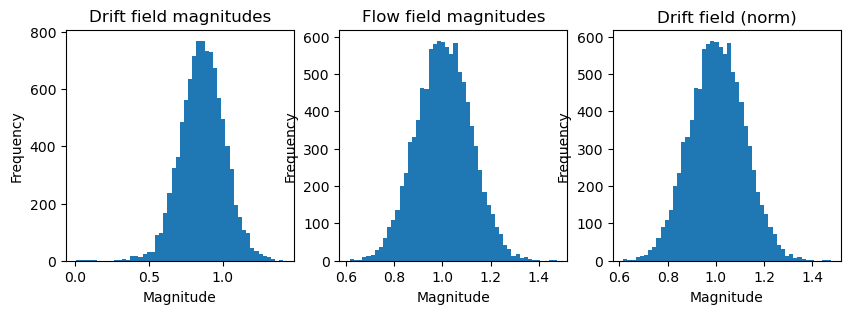

In [27]:
lengths = drift_fields.norm(dim=-1)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
ax = axes[0]
ax.hist(lengths.cpu().numpy(), bins=50)
ax.set_title("Drift field magnitudes")
ax.set_xlabel("Magnitude")
ax.set_ylabel("Frequency")

ax = axes[1]
flow_field_lenghts = straight_fields.norm(dim=-1)
ax.hist(flow_field_lenghts.cpu().numpy(), bins=50)
ax.set_title("Flow field magnitudes")
ax.set_xlabel("Magnitude")
ax.set_ylabel("Frequency")


# norm_drift_fields 
norm_lengths = norm_drift_fields.norm(dim=-1)
ax = axes[2]
ax.hist(norm_lengths.cpu().numpy(), bins=50)
ax.set_title("Drift field (norm)")
ax.set_xlabel("Magnitude")
ax.set_ylabel("Frequency")

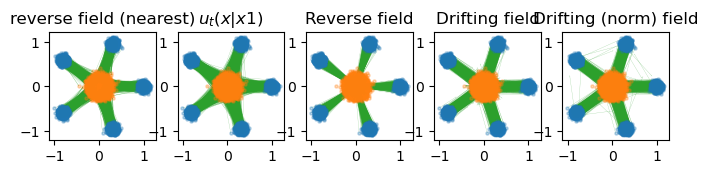

In [28]:
fig, axes = plt.subplots(1, 5, figsize=(8, 4))
# # drift = compute_drift(x0, x1, temp=1)
# drift = avg_drift(x0, x1)

# vector_field = drift
ax = axes[0]
# Plot vector field, starting at x0 and pointing towards xo+vector_field
ax.quiver(pos[:, 0], pos[:, 1], nearest_drift_fields[:, 0], nearest_drift_fields[:, 1], angles='xy', scale_units='xy', scale=1, alpha=0.5, color='tab:green')    

# ax.quiver(x0[:, 0], x0[:, 1], vector_field[:, 0], vector_field[:, 1], angles='xy', scale_units='xy', scale=1, alpha=0.5, color='tab:green')    
ax.scatter(data[:, 0], data[:, 1], s=5, alpha=0.3, c='tab:blue')
ax.scatter(prior[:, 0], prior[:, 1], s=5, alpha=0.3, c='tab:orange')
ax.set_title(r"reverse field (nearest)")
ax.set_aspect('equal')

ax = axes[1]
# vector_field = x1 - x0
# Plot vector field, starting at x0 and pointing towards xo+vector_field
ax.quiver(neg[:, 0], neg[:, 1], straight_fields[:, 0], straight_fields[:, 1], angles='xy', scale_units='xy', scale=1, alpha=0.5, color='tab:green')    
ax.scatter(data[:, 0], data[:, 1], s=5, alpha=0.3, c='tab:blue')
ax.scatter(prior[:, 0], prior[:, 1], s=5, alpha=0.3, c='tab:orange')
ax.set_title(r"$u_t(x|x1)$")
ax.set_aspect('equal')

ax = axes[2]
# vector_field = x1 - x0
# Plot vector field, starting at x0 and pointing towards xo+vector_field
ax.quiver(pos[:, 0], pos[:, 1], reverse_drift_fields[:, 0], reverse_drift_fields[:, 1], angles='xy', scale_units='xy', scale=1, alpha=0.5, color='tab:green')    
ax.scatter(data[:, 0], data[:, 1], s=5, alpha=0.3, c='tab:blue')
ax.scatter(prior[:, 0], prior[:, 1], s=5, alpha=0.3, c='tab:orange')
ax.set_title(r"Reverse field")
ax.set_aspect('equal')

ax = axes[3]
ax.quiver(pos[:, 0], pos[:, 1], drift_fields[:, 0], drift_fields[:, 1], angles='xy', scale_units='xy', scale=1, alpha=0.5, color='tab:green')    
ax.scatter(data[:, 0], data[:, 1], s=5, alpha=0.3, c='tab:blue')
ax.scatter(prior[:, 0], prior[:, 1], s=5, alpha=0.3, c='tab:orange')
ax.set_title(r"Drifting field")
ax.set_aspect('equal')

ax = axes[4]
ax.quiver(pos[:, 0], pos[:, 1], norm_drift_fields[:, 0], norm_drift_fields[:, 1], angles='xy', scale_units='xy', scale=1, alpha=0.5, color='tab:green')    
ax.scatter(data[:, 0], data[:, 1], s=5, alpha=0.3, c='tab:blue')
ax.scatter(prior[:, 0], prior[:, 1], s=5, alpha=0.3, c='tab:orange')
ax.set_title(r"Drifting (norm) field")
ax.set_aspect('equal')
# plt.show()

In [ ]:
x1 = torch.tensor([[2.0, 2.0], [1.0, 1.0], [3.0, 3.0]])

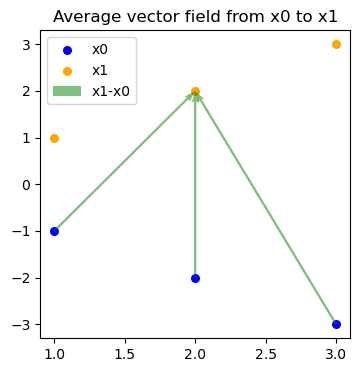

In [40]:
x1 = torch.tensor([[2.0, 2.0], [1.0, 1.0], [3.0, 3.0]])
x0 = torch.tensor([[1.0, -1.0], [2.0, -2.0], [3.0, -3.0]])
# vectors = (x1[None,...] - x0[:,None,...]).mean(dim=1)

plt.figure(figsize=(4, 4))
plt.scatter(x0[:, 0], x0[:, 1], s=30, c='blue', label='x0')
plt.scatter(x1[:, 0], x1[:, 1], s=30, c='orange', label='x1')
vectors = (x1[None,...] - x0[:,None,...]).mean(dim=1)
# vectors = x1 - x0
plt.quiver(x0[:, 0], x0[:, 1], vectors[:, 0], vectors[:, 1], angles='xy', scale_units='xy', scale=1, alpha=0.5, color='green', label='x1-x0')
plt.legend()
plt.title("Average vector field from x0 to x1")
plt.show()


In [99]:
x1 = torch.tensor([[2.0, 2.0], [1.0, 1.0], [3.0, 3.0]])
x = torch.randn(1, 2)

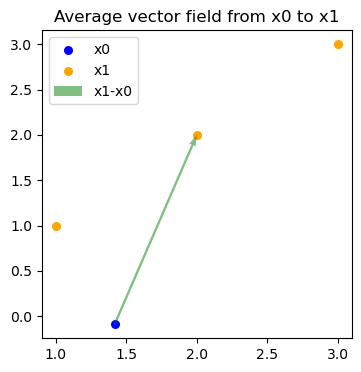

In [43]:


x1 = torch.tensor([[2.0, 2.0], [1.0, 1.0], [3.0, 3.0]])
# vectors = (x1[None,...] - x0[:,None,...]).mean(dim=1)
plt.figure(figsize=(4, 4))
plt.scatter(x[:, 0], x[:, 1], s=30, c='blue', label='x0')
plt.scatter(x1[:, 0], x1[:, 1], s=30, c='orange', label='x1')

vectors = (x1[None,...] - x[:,None,...]).mean(dim=1)

plt.quiver(x[:, 0], x[:, 1], vectors[:, 0], vectors[:, 1], angles='xy', scale_units='xy', scale=1, alpha=0.5, color='green', label='x1-x0')
plt.legend()
plt.title("Average vector field from x0 to x1")
plt.show()



In [ ]:
vectors = []
distances = []
for pt in x1:
    vector = (pt - x)
    distances.append(vector.norm().item())
    vectors.append(vector)
vectors = torch.stack(vectors, dim=0)
distances = torch.tensor(distances)

kernel = (-distances / 1.0).exp()
normalized_kernel = kernel / kernel.sum()

weighted_vectors = normalized_kernel[:,None, None]*vectors
vector = weighted_vectors.sum(dim=0)

In [4]:
x1 = torch.tensor([[2.0, 2.0], [1.0, 1.0], [3.0, 3.0]])
x = torch.randn(1, 2)

In [5]:
x = torch.cat([x, x], dim=0)

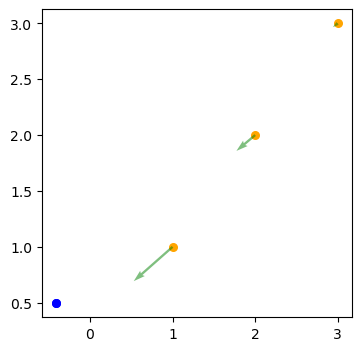

In [8]:
# drift = avg_drift(x, x1, temp=1.0)
drift = compute_drift(x1, x, temp=1.0)

plt.figure(figsize=(4, 4))
plt.scatter(x[:, 0], x[:, 1], s=30, c='blue', label='x0')
plt.scatter(x1[:, 0], x1[:, 1], s=30, c='orange', label='x1')
plt.quiver(x1[:, 0], x1[:, 1], drift[:, 0], drift[:, 1], angles='xy', scale_units='xy', scale=1, alpha=0.5, color='green', label='x1-x0')
# plt.quiver(x[:, 0], x[:, 1], drift[:, 0], drift[:, 1], angles='xy', scale_units='xy', scale=1, alpha=0.5, color='green', label='x1-x0')


In [177]:
drift.shape

torch.Size([3, 2])

In [140]:
x.shape

torch.Size([2, 2])

In [143]:
vectors = x1[None,:] - x[:,None]
# distances = torch.cdist(x, x1).shape
distances = vectors.norm(dim=-1)
kernel = (-distances / 1.0).exp()
normalized_kernel = kernel / kernel.sum(dim=-1, keepdim=True)
# weighted_vectors = normalized_kernel[:,:,None]*vectors
# field = weighted_vectors.sum(dim=1)
indices = normalized_kernel.argmax(dim=0)
field = vectors[indices, torch.arange(indices.shape[0])]
# field = vectors[torch.arange(x.shape[0]), indices]

In [146]:
indices

tensor([0, 0, 0])

In [135]:
vectors.shape

torch.Size([2, 3, 2])

In [134]:
normalized_kernel.shape

torch.Size([2, 3])

In [121]:
normalized_kernel.argmax(dim=-1)

tensor([1, 1])

In [144]:
field.shape

torch.Size([3, 2])

In [101]:
normalized_kernel.argmax(dim=-1)

tensor([1])

In [103]:
vectors.shape

torch.Size([1, 3, 2])

In [102]:
normalized_kernel.shape

torch.Size([1, 3])

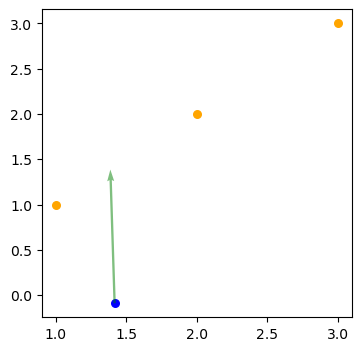

In [70]:
vectors.shape

torch.Size([3, 1, 2])

In [67]:
distances.shape

torch.Size([3])

In [69]:
torch.cdist(x, x1).shape

torch.Size([1, 3])

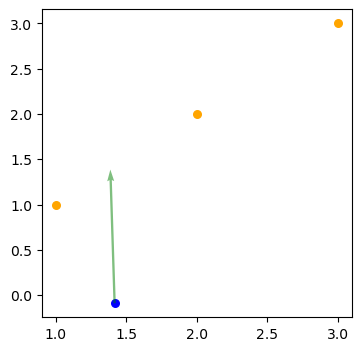

In [66]:
plt.figure(figsize=(4, 4))
plt.scatter(x[:, 0], x[:, 1], s=30, c='blue', label='x0')
plt.scatter(x1[:, 0], x1[:, 1], s=30, c='orange', label='x1')
plt.quiver(x[:, 0], x[:, 1], vector[:, 0], vector[:, 1], angles='xy', scale_units='xy', scale=1, alpha=0.5, color='green', label='x1-x0')


In [53]:
vectors.shape

torch.Size([3, 1, 2])

In [33]:
vectors.shape

torch.Size([1024, 1024, 2])

In [ ]:
r = 1
n_components = 5
centroids = torch.tensor([
    [r * math.cos(2 * math.pi * i / n_components), r * math.sin(2 * math.pi * i / n_components)]
    for i in range(n_components)
])

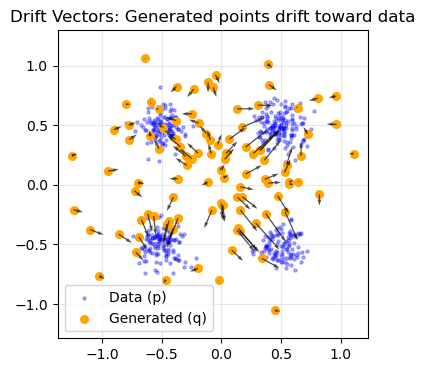

In [6]:
# Quick visualization of drift vectors
torch.manual_seed(42)

# Random generated points (from Gaussian)
gen_test = torch.randn(100, 2) * 0.5

# Target data: simple 4-mode Gaussian mixture
centers = torch.tensor([[-0.5, -0.5], [-0.5, 0.5], [0.5, -0.5], [0.5, 0.5]])
idx = torch.randint(0, 4, (500,))
pos_test = centers[idx] + torch.randn(500, 2) * 0.1

# Compute drift
drift_test = compute_drift(gen_test, pos_test, temp=0.2)

# Plot
plt.figure(figsize=(4, 4))
plt.scatter(pos_test[:, 0], pos_test[:, 1], s=5, alpha=0.3, c='blue', label='Data (p)')
plt.scatter(gen_test[:, 0], gen_test[:, 1], s=30, c='orange', label='Generated (q)')
plt.quiver(gen_test[:, 0], gen_test[:, 1], drift_test[:, 0], drift_test[:, 1],
           scale=3, color='black', alpha=0.7, width=0.004)
plt.legend()
plt.title('Drift Vectors: Generated points drift toward data')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

### part-2

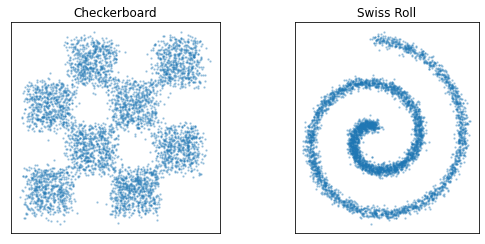

In [ ]:



# quick look
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, (name, sampler) in zip(axes, [("Checkerboard", sample_checkerboard), ("Swiss Roll", sample_swiss_roll)]):
    pts = sampler(5000).numpy()
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.3)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Training Loop for Toy 2D
# ============================================================
from functools import partial
class MLP(nn.Module):
    """MLP: noise -> output. 3 hidden layers with SiLU."""
    def __init__(self, in_dim=32, hidden=256, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, z):
        return self.net(z)

def train_toy(sampler, steps=2000, data_batch_size=2048, gen_batch_size=2048, lr=1e-3, temp=0.05,
              in_dim=32, hidden=256, plot_every=500, seed=42):
    """Train drifting model. Returns model and loss history."""
    torch.manual_seed(seed)
    model = MLP(in_dim=in_dim, hidden=hidden, out_dim=2).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    
    loss_history = []
    ema = None
    pbar = tqdm(range(1, steps + 1))
    for step in pbar:
        pos = sampler(data_batch_size).to(DEVICE)
        gen = model(torch.randn(gen_batch_size, in_dim, device=DEVICE))
        loss = drifting_loss(gen, pos, compute_drift=partial(compute_drift, temp=temp))
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
        loss_history.append(loss.item())
        ema = loss.item() if ema is None else 0.96 * ema + 0.04 * loss.item()
        pbar.set_postfix(loss=f"{ema:.2e}")
        
        if step % plot_every == 0 or step == 1:
            with torch.no_grad():
                vis = model(torch.randn(5000, in_dim, device=DEVICE)).cpu().numpy()
                gt = sampler(5000).numpy()
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
            ax1.scatter(gt[:, 0], gt[:, 1], s=2, alpha=0.3, c='black')
            ax1.set_title('Target'); ax1.set_aspect('equal'); ax1.axis('off')
            ax2.scatter(vis[:, 0], vis[:, 1], s=2, alpha=0.3, c='tab:orange')
            ax2.set_title(f'Generated (step {step})'); ax2.set_aspect('equal'); ax2.axis('off')
            plt.tight_layout(); plt.show()
    
    return model, loss_history

Training on Swiss Roll...


  0%|          | 0/2000 [00:00<?, ?it/s]

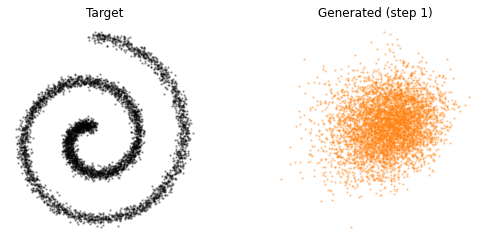

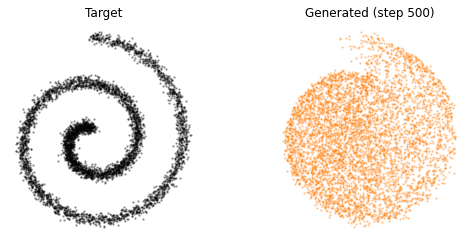

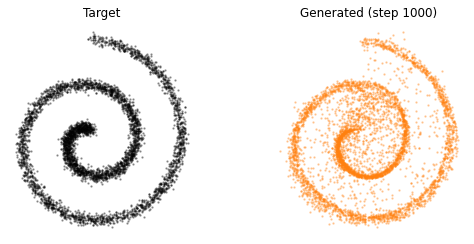

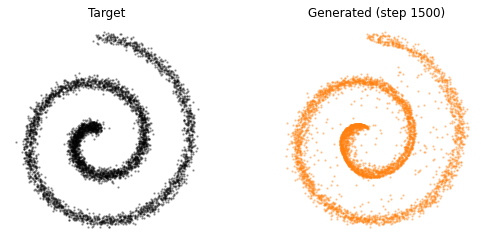

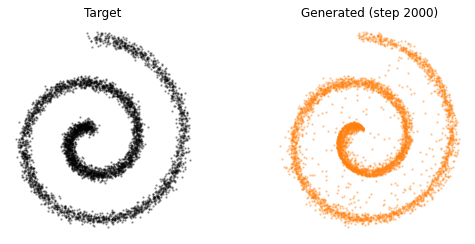

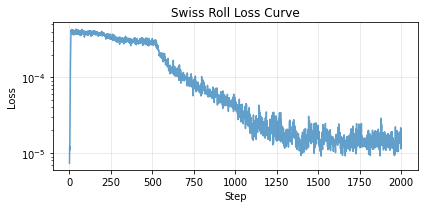

In [11]:
# Train on Swiss Roll
print("Training on Swiss Roll...")
model_swiss, loss_swiss = train_toy(sample_swiss_roll, steps=2000, lr=1e-3, temp=0.05)

plt.figure(figsize=(6, 3))
plt.plot(loss_swiss, alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Swiss Roll Loss Curve')
plt.yscale('log'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


In [ ]:

# Train on Checkerboard
print("\nTraining on Checkerboard...")
model_checker, loss_checker = train_toy(sample_checkerboard, steps=2000, lr=1e-3, temp=0.05)

plt.figure(figsize=(6, 3))
plt.plot(loss_checker, alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Checkerboard Loss Curve')
plt.yscale('log'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()